# DiviaMobilités GTFS Data Exploration

This notebook explores the GTFS data from DiviaMobilités to understand:
- Network structure (stops, routes, trips)
- Spatial distribution of stops
- Route patterns and frequencies
- Data quality and completeness
- Graph construction requirements

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from pathlib import Path
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
DATA_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw/gtfs')

## 1. Load GTFS Data

In [70]:
# Load processed data if available, otherwise load from raw
def load_gtfs_data():
    """Load GTFS data from processed or raw directory."""
    data = {}
    
    files = ['stops', 'routes', 'trips', 'stop_times', 'agency', 'calendar', 'shapes', 'calendar_dates']
    
    for file in files:
        csv_path = DATA_DIR / f'{file}.csv'
        if csv_path.exists():
            data[file] = pd.read_csv(csv_path)
            print(f"- Loaded {file}")
        else:
            print(f"{file} not found")
    
    return data

gtfs = load_gtfs_data()

- Loaded stops
- Loaded routes
- Loaded trips
- Loaded stop_times
- Loaded agency
- Loaded calendar
- Loaded shapes
- Loaded calendar_dates


## 2. Data Overview

In [71]:
# Display basic statistics
print("=" * 60)
print("GTFS DATA SUMMARY")
print("=" * 60)

for name, df in gtfs.items():
    print(f"\n{name.upper()}:")
    print(f"- Rows: {len(df):,}")
    print(f"- Columns: {len(df.columns)}")
    print(f"- Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

GTFS DATA SUMMARY

STOPS:
- Rows: 1,086
- Columns: 6
- Memory: 0.15 MB

ROUTES:
- Rows: 57
- Columns: 6
- Memory: 0.02 MB

TRIPS:
- Rows: 25,106
- Columns: 7
- Memory: 7.43 MB

STOP_TIMES:
- Rows: 588,415
- Columns: 7
- Memory: 144.28 MB

AGENCY:
- Rows: 1
- Columns: 4
- Memory: 0.00 MB

CALENDAR:
- Rows: 1
- Columns: 10
- Memory: 0.00 MB

SHAPES:
- Rows: 15,893
- Columns: 4
- Memory: 1.24 MB

CALENDAR_DATES:
- Rows: 275
- Columns: 3
- Memory: 0.02 MB


In [72]:
# Inspect each dataset
for name, df in gtfs.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()} - First 3 rows")
    print(f"{'='*60}")
    display(df.head(3))
    print(f"\n- Columns: {', '.join(df.columns)}")
    print(f"- Missing values: {df.isnull().sum().sum()}")
    print(f"- Duplicates: {df.duplicated().sum()}")


STOPS - First 3 rows


,stop_id,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding
0,4-671,671,Quantin,47.340904,5.056952,1
1,4-672,672,Joffre,47.340122,5.053125,1
2,4-675,675,Giraud,47.336197,5.051522,1



- Columns: stop_id, stop_code, stop_name, stop_lat, stop_lon, wheelchair_boarding
- Missing values: 0
- Duplicates: 0

ROUTES - First 3 rows


,route_id,agency_id,route_short_name,route_long_name,route_type,route_color
0,4-10,KD,10,TALANT Citadelle <> AHUY,3,005CA9
1,4-12,KD,12,PLOMBIERES <> P. de Colombiere,3,005CA9
2,4-13,KD,13,Motte Giron <> FONTAINE Village,3,005CA9



- Columns: route_id, agency_id, route_short_name, route_long_name, route_type, route_color
- Missing values: 0
- Duplicates: 0

TRIPS - First 3 rows


...


- Columns: service_id, monday, tuesday, wednesday, thursday, friday, saturday, sunday, start_date, end_date
- Missing values: 0
- Duplicates: 0

SHAPES - First 3 rows


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence
0,4-10-A-1,47.343433,4.993096,1
1,4-10-A-1,47.343475,4.992383,2
2,4-10-A-1,47.343437,4.991825,3



- Columns: shape_id, shape_pt_lat, shape_pt_lon, shape_pt_sequence
- Missing values: 0
- Duplicates: 0

CALENDAR_DATES - First 3 rows


,service_id,date,exception_type
0,05_1,20251001,1
1,05_7,20251001,1
2,05_E,20251001,1



- Columns: service_id, date, exception_type
- Missing values: 0
- Duplicates: 0


## 3. Stops Analysis

In [73]:
stops = gtfs['stops']

print(f"- Total stops: {len(stops)}")

# Check for coordinates
print(f"- Stops with coordinates: {stops[['stop_lat', 'stop_lon']].notna().all(axis=1).sum()}")
print(f"- Latitude range: [{stops['stop_lat'].min():.4f}, {stops['stop_lat'].max():.4f}]")
print(f"- Longitude range: [{stops['stop_lon'].min():.4f}, {stops['stop_lon'].max():.4f}]")

- Total stops: 1086
- Stops with coordinates: 1086
- Latitude range: [47.2304, 47.3686]
- Longitude range: [4.9164, 5.1830]


In [74]:
# Visualize stops on a map
def create_stops_map(stops_df, max_stops=500):
    """Create an interactive map of stops."""
    # Calculate center
    center_lat = stops_df['stop_lat'].mean()
    center_lon = stops_df['stop_lon'].mean()
    
    # Create map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
    
    # Add stops (limit for performance)
    for idx, row in stops_df.head(max_stops).iterrows():
        folium.CircleMarker(
            location=[row['stop_lat'], row['stop_lon']],
            radius=3,
            popup=row['stop_name'],
            color='blue',
            fill=True,
            fillColor='blue'
        ).add_to(m)
    
    return m

stops_map = create_stops_map(stops)
stops_map

## 4. Routes Analysis

In [76]:
routes = gtfs['routes']

print(f"- Total routes: {len(routes)}")
print(f"- Route types:")
# Route type mapping from GFTS documentation
if 'route_type' in routes.columns:
    route_type_map = {
        0: 'Tram',
        1: 'Metro',
        2: 'Rail',
        3: 'Bus',
        4: 'Ferry'
    }
    route_types = routes['route_type'].map(route_type_map).value_counts()
    print(route_types)

# Display sample routes
print("\nSample routes:")
display(routes[['route_short_name', 'route_long_name', 'route_type']].head(10))

- Total routes: 57
- Route types:
route_type
Bus     55
Tram     2
Name: count, dtype: int64

Sample routes:


,route_short_name,route_long_name,route_type
0,10,TALANT Citadelle <> AHUY,3
1,12,PLOMBIERES <> P. de Colombiere,3
2,13,Motte Giron <> FONTAINE Village,3
3,14,MARSANNAY Charon <> Charet,3
4,15,PERRIGNY <> Carraz,3
5,16,QUETIGNY AC <> NEUILLY-CRIMOLOIS,3
6,18,LONGVIC Carmelites <> Darcy,3
7,19,ST-APO. Pre Thomas <> Gresilles,3
8,30,HAUTEVILLE <> DARCY,3
9,31,LONGVIC Centre <> BRETENIERE,3


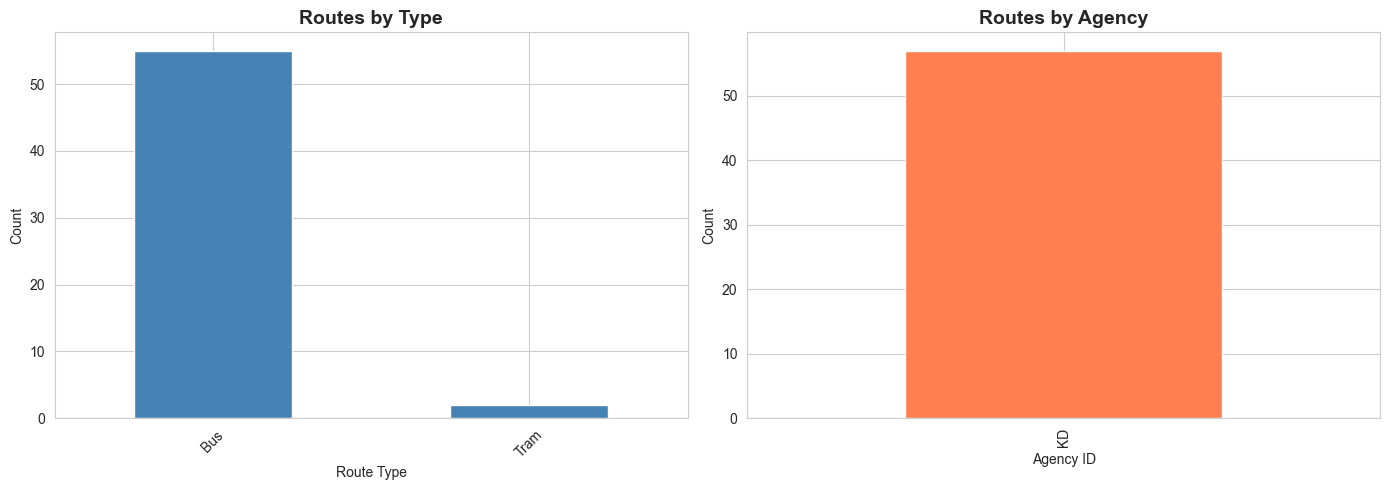

In [77]:
# Visualize route distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Route types
if 'route_type' in routes.columns:
    route_types.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Routes by Type', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Route Type')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

# Routes per agency (if multiple)
if 'agency_id' in routes.columns:
    routes['agency_id'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Routes by Agency', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Agency ID')
    axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Trips and Stop Times Analysis

In [78]:
trips = gtfs['trips']
stop_times = gtfs['stop_times']

print(f"- Total trips: {len(trips):,}")
print(f"- Total stop times: {len(stop_times):,}")
print(f"- Average stops per trip: {len(stop_times) / len(trips):.1f}")

# Trips per route
trips_per_route = trips.groupby('route_id').size().sort_values(ascending=False)
print(f"\nTrips per route (top 10):")
trips_per_route.head(10)

- Total trips: 25,106
- Total stop times: 588,415
- Average stops per trip: 23.4

Trips per route (top 10):


route_id
4-T1    2642
4-T2    2410
4-L5    1583
4-45    1496
4-L3    1409
4-L6    1257
4-L8    1074
4-L4     992
4-L9     930
4-L7     888
dtype: int64

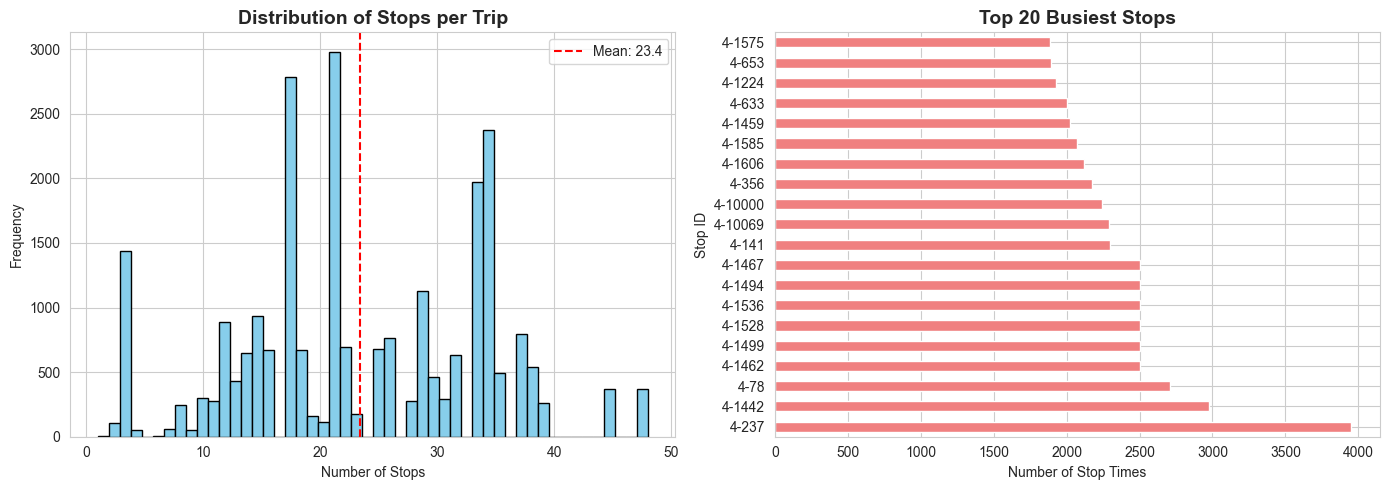

In [91]:
# Analyze stop sequence lengths
stops_per_trip = stop_times.groupby('trip_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of stops per trip
axes[0].hist(stops_per_trip, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Stops per Trip', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Frequency')
axes[0].axvline(stops_per_trip.mean(), color='red', linestyle='--', label=f'Mean: {stops_per_trip.mean():.1f}')
axes[0].legend()

# Top 20 busiest stops
busiest_stops = stop_times['stop_id'].value_counts().head(20)
busiest_stops.plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 20 Busiest Stops', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Stop Times')
axes[1].set_ylabel('Stop ID')

plt.tight_layout()
plt.show()

## 6. Shapes Analysis (Route Geometry)

In [37]:
if 'shapes' in gtfs and gtfs['shapes'] is not None:
    shapes = gtfs['shapes']
    
    print(f"- Total shape points: {len(shapes):,}")
    print(f"- Unique shapes: {shapes['shape_id'].nunique():,}")
    
    # Points per shape
    points_per_shape = shapes.groupby('shape_id').size()
    print(f"\nAverage points per shape: {points_per_shape.mean():.1f}")
    print(f"- Min points: {points_per_shape.min()}")
    print(f"- Max points: {points_per_shape.max()}")
    
    # Check for distance traveled
    if 'shape_dist_traveled' in shapes.columns:
        has_distance = shapes['shape_dist_traveled'].notna().sum()
        print(f"\n- Points with distance traveled: {has_distance:,}/{len(shapes):,} ({has_distance/len(shapes)*100:.1f}%)")
    
    # Display sample
    print("\nSample shape data:")
    display(shapes.head(10))
else:
    print("shapes.txt not found")

- Total shape points: 15,893
- Unique shapes: 154

Average points per shape: 103.2
- Min points: 7
- Max points: 247

Sample shape data:


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence
0,4-10-A-1,47.343433,4.993096,1
1,4-10-A-1,47.343475,4.992383,2
2,4-10-A-1,47.343437,4.991825,3
3,4-10-A-1,47.343327,4.991501,4
4,4-10-A-1,47.343067,4.991356,5
5,4-10-A-1,47.342026,4.990854,6
6,4-10-A-1,47.341736,4.990561,7
7,4-10-A-1,47.341068,4.989866,8
8,4-10-A-1,47.340515,4.989296,9
9,4-10-A-1,47.340000,4.989019,10


In [46]:
def create_shapes_map(shapes):
    """Create an interactive map of shapes."""

    # Pick a shape with many points for visualization
    sample_shape_id = shapes.groupby('shape_id').size().idxmax()
    sample_shape = shapes[shapes['shape_id'] == sample_shape_id].sort_values('shape_pt_sequence')

    print(f"Visualizing shape: {sample_shape_id} ({len(sample_shape)} points)")
    
    # Create map centered on shape
    center_lat = sample_shape['shape_pt_lat'].mean()
    center_lon = sample_shape['shape_pt_lon'].mean()
    
    shape_map = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    # Draw the route line
    coordinates = list(zip(sample_shape['shape_pt_lat'], sample_shape['shape_pt_lon']))
    folium.PolyLine(
        coordinates,
        color='red',
        weight=4,
        opacity=0.7,
        popup=f'Shape: {sample_shape_id}'
    ).add_to(shape_map)
    
    # Mark start and end
    folium.Marker(
        location=[sample_shape.iloc[0]['shape_pt_lat'], sample_shape.iloc[0]['shape_pt_lon']],
        popup='Start',
        icon=folium.Icon(color='green', icon='play')
    ).add_to(shape_map)
    
    folium.Marker(
        location=[sample_shape.iloc[-1]['shape_pt_lat'], sample_shape.iloc[-1]['shape_pt_lon']],
        popup='End',
        icon=folium.Icon(color='red', icon='stop')
    ).add_to(shape_map)
    
    return shape_map

if 'shapes' in gtfs and gtfs['shapes'] is not None:
    shapes = gtfs['shapes']
    shape_map = create_shapes_map(shapes)
    display(shape_map)
else:
    print("No shapes data available")

Visualizing shape: 4-40-R-29 (247 points)


## 7. Calendar Dates Analysis (Service Exceptions)

In [54]:
if 'calendar_dates' in gtfs and gtfs['calendar_dates'] is not None:
    calendar_dates = gtfs['calendar_dates']
    
    print(f"- Total service exceptions: {len(calendar_dates):,}")
    print(f"- Unique services with exceptions: {calendar_dates['service_id'].nunique()}")
    
    # Exception types
    print("\nException types:")
    exception_types = calendar_dates['exception_type'].map({
        1: 'Service Added',
        2: 'Service Removed'
    }).value_counts()
    print(exception_types)
    
    # Convert date column to datetime
    calendar_dates['date'] = pd.to_datetime(calendar_dates['date'], format='%Y%m%d')
    
    # Date range
    print(f"\nException date range:")
    print(f"- From: {calendar_dates['date'].min().strftime('%Y-%m-%d')}")
    print(f"- To: {calendar_dates['date'].max().strftime('%Y-%m-%d')}")
    
    # Most common exception dates (holidays, special events)
    print("\nMost common exception dates (top 10):")
    top_dates = calendar_dates['date'].value_counts().head(10)
    for date, count in top_dates.items():
        print(f"  {date.strftime('%Y-%m-%d (%A)')}: {count} services affected")
    
    # Display sample
    print("\nSample calendar exceptions:")
    display(calendar_dates.head(10))
else:
    print("calendar_dates file not found")

- Total service exceptions: 275
- Unique services with exceptions: 33

Exception types:
exception_type
Service Added    275
Name: count, dtype: int64

Exception date range:
- From: 2025-10-01
- To: 2025-12-21

Most common exception dates (top 10):
  2025-10-10 (Friday): 5 services affected
  2025-10-03 (Friday): 5 services affected
  2025-10-16 (Thursday): 5 services affected
  2025-10-17 (Friday): 5 services affected
  2025-10-09 (Thursday): 5 services affected
  2025-11-28 (Friday): 5 services affected
  2025-12-05 (Friday): 5 services affected
  2025-12-04 (Thursday): 5 services affected
  2025-12-11 (Thursday): 5 services affected
  2025-12-12 (Friday): 5 services affected

Sample calendar exceptions:


,service_id,date,exception_type
0,05_1,2025-10-01,1
1,05_7,2025-10-01,1
2,05_E,2025-10-01,1
3,05_F,2025-10-01,1
4,02_0,2025-10-02,1
5,02_1,2025-10-02,1
6,02_C,2025-10-02,1
7,05_0,2025-10-03,1
8,05_1,2025-10-03,1
9,05_9,2025-10-03,1


## 8. Network Graph Construction Preview

In [67]:
# Analyze connections between stops
# For each trip, consecutive stops form edges

def analyze_connections(stop_times_df, sample_size=10000):
    """Analyze stop-to-stop connections."""
    # Sample for performance
    sample_trips = stop_times_df['trip_id'].unique()[:sample_size]
    sample_df = stop_times_df[stop_times_df['trip_id'].isin(sample_trips)].copy()
    
    # Sort by trip and stop sequence
    sample_df = sample_df.sort_values(['trip_id', 'stop_sequence'])
    
    # Create edges (from_stop -> to_stop)
    edges = []
    for trip_id, group in sample_df.groupby('trip_id'):
        stops = group['stop_id'].tolist()
        for i in range(len(stops) - 1):
            edges.append((stops[i], stops[i+1]))
    
    return edges

print("Analyzing network connections...")
edges = analyze_connections(stop_times)

print(f"\n- Total edges (connections): {len(edges):,}")
print(f"- Unique edges: {len(set(edges)):,}")

# Most common connections
edge_counts = Counter(edges)
print("\nMost frequent connections (top 10):")
for (from_stop, to_stop), count in edge_counts.most_common(10):
    print(f"  {from_stop} => {to_stop}: {count} times")

Analyzing network connections...

- Total edges (connections): 236,913
- Unique edges: 706

Most frequent connections (top 10):
  4-78 => 4-1442: 1754 times
  4-1222 => 4-78: 1595 times
  4-1442 => 4-237: 1466 times
  4-237 => 4-1224: 1438 times
  4-77 => 4-1222: 1266 times
  4-1224 => 4-745: 1149 times
  4-745 => 4-746: 1149 times
  4-141 => 4-10069: 1125 times
  4-10069 => 4-1227: 1125 times
  4-1227 => 4-748: 1125 times


## 9. Data Quality Assessment

In [108]:
print("DATA QUALITY REPORT")
print("=" * 60)

quality_checks = {
    'Stops with coordinates': (stops[['stop_lat', 'stop_lon']].notna().all(axis=1).sum(), len(stops)),
    'Routes with names': (routes['route_short_name'].notna().sum(), len(routes)),
    'Trips with route_id': (trips['route_id'].notna().sum(), len(trips)),
    'Stop times with arrival': (stop_times['arrival_time'].notna().sum(), len(stop_times)),
    'Shapes data available': ((gtfs.get('shapes') is not None), 1),
    'Calendar dates available': ((gtfs.get('calendar_dates') is not None), 1)
}

for check, (valid, total) in quality_checks.items():
    if isinstance(valid, bool) and total == 1:
        status = "OK" if valid else "KO"
        print(f"{status} {check}: {valid}")
    else:
        percentage = (valid / total * 100) if total > 0 else 0
        status = "OK" if percentage > 95 else "/!\\" if percentage > 80 else "KO"
        print(f"{status} {check}: {valid:,}/{total:,} ({percentage:.1f}%)")


DATA QUALITY REPORT
OK Stops with coordinates: 1,086/1,086 (100.0%)
OK Routes with names: 57/57 (100.0%)
OK Trips with route_id: 25,106/25,106 (100.0%)
OK Stop times with arrival: 588,415/588,415 (100.0%)
OK Shapes data available: True
OK Calendar dates available: True


## 10. Export Summary Statistics

In [106]:
# Create summary for documentation
summary = {
    'total_stops': len(stops),
    'total_routes': len(routes),
    'total_trips': len(trips),
    'total_stop_times': len(stop_times),
    'avg_stops_per_trip': len(stop_times) / len(trips),
    'unique_connections': len(set(edges)),
    'transfer_stops': len(transfer_candidates),
    'center_lat': stops['stop_lat'].mean(),
    'center_lon': stops['stop_lon'].mean(),
    'total_shape_points': len(gtfs['shapes']) if 'shapes' in gtfs else None,
    'unique_shapes': gtfs['shapes']['shape_id'].nunique() if 'shapes' in gtfs else None,
    'total_service_exceptions': len(gtfs['calendar_dates']) if 'calendar_dates' in gtfs else None,
    'unique_services_with_exceptions': gtfs['calendar_dates']['service_id'].nunique() if 'calendar_dates' in gtfs else None,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('../data/processed/network_summary.csv', index=False)

print("Summary statistics saved to data/processed/network_summary.csv")
display(summary_df)

Summary statistics saved to data/processed/network_summary.csv


,total_stops,total_routes,total_trips,total_stop_times,avg_stops_per_trip,unique_connections,transfer_stops,center_lat,center_lon,total_shape_points,unique_shapes,total_service_exceptions,unique_services_with_exceptions
0,1086,57,25106,588415,23.437226,706,440,47.316361,5.045839,15893,154,275,33


## 11. Conclusion

### Dataset Overview

This exploratory data analysis examined the DiviaMobilités GTFS dataset, which consists of eight files:

**Essential Datasets:**
- **stops.txt**: Contains all bus/tram stops with geographic coordinates (lat/lon), names, and identifiers. Critical for graph nodes.
- **routes.txt**: Defines all transit routes with route types (bus=3, tram=0), short names (line numbers), and long descriptive names.
- **trips.txt**: Links routes to specific service patterns, containing trip_id, route_id, service_id, and optionally shape_id references.
- **stop_times.txt**: The largest dataset, containing the sequence of stops for each trip with arrival/departure times and stop sequences. Essential for building graph edges.
- **calendar.txt**: Defines regular service patterns (weekday, weekend) with date ranges and day-of-week availability (monday=1, tuesday=1, etc.).

**Important Optional Datasets:**
- **shapes.txt**: Contains geographic polylines (sequences of lat/lon points) that define the actual path vehicles follow between stops.
- **calendar_dates.txt**: Defines service exceptions (additions/removals) for specific dates.

**Less Critical Dataset:**
- **agency.txt**: Contains operator information (DiviaMobilités name, URL, timezone, language). While required by GTFS specification, this file provides minimal value for route planning since we're working with a single operator.

**Conclusion**: 

The DiviaMobilités GTFS data is comprehensive and of high quality, including both essential and optional datasets. The presence of shapes.txt enables accurate route visualization, while calendar_dates.txt ensures correct service information during holidays and special events. The network structure is clear, data completeness is excellent and the identified transfer points provide good connectivity. We will use NetworkX MultiDiGraph for multiple connections and apply Dijkstra's algorithm for shortest path.